In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [27]:
df = pd.read_csv('../data/processed/training.csv')

In [28]:
correlation_matrix = df.corr(numeric_only=True)
display(correlation_matrix['stable'].sort_values(ascending=False))

stable             1.000000
type_A1A2B1B2O6    0.490991
EH-B1              0.397028
B1_OS              0.377717
R-A2               0.367126
                     ...   
type_ABO3         -0.337938
EH-A2             -0.358376
L-B1              -0.360627
BE-A2             -0.366636
A2_OS             -0.436153
Name: stable, Length: 63, dtype: float64

In [29]:
from scipy.stats import pearsonr, spearmanr, kendalltau

correlation_results = {}

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols.remove('stable')


for col in numeric_cols:

    temp_df = df[[col, 'stable']].dropna()
    if len(temp_df) > 1:
        pearson_corr, _ = pearsonr(temp_df[col], temp_df['stable'])
        spearman_corr, _ = spearmanr(temp_df[col], temp_df['stable'])
        kendall_corr, _ = kendalltau(temp_df[col], temp_df['stable'])

        correlation_results[col] = {
            'Pearson': pearson_corr,
            'Spearman': spearman_corr,
            'Kendall': kendall_corr
        }
    else:
        correlation_results[col] = {
            'Pearson': None,
            'Spearman': None,
            'Kendall': None
        }



for col, corrs in correlation_results.items():
    print(f"Correlations with stable for column '{col}':")
    for method, value in corrs.items():
        print(f"  {method}: {value:.4f}" if value is not None else f"  {method}: Insufficient data")
    print("-" * 20)

Correlations with stable for column 'A1_OS':
  Pearson: -0.0085
  Spearman: -0.0237
  Kendall: -0.0227
--------------------
Correlations with stable for column 'A2_OS':
  Pearson: -0.4362
  Spearman: -0.4431
  Kendall: -0.4185
--------------------
Correlations with stable for column 'B1_OS':
  Pearson: 0.3777
  Spearman: 0.4007
  Kendall: 0.3700
--------------------
Correlations with stable for column 'B2_OS':
  Pearson: -0.0457
  Spearman: -0.0766
  Kendall: -0.0724
--------------------
Correlations with stable for column 'Insulator':
  Pearson: -0.1811
  Spearman: -0.1811
  Kendall: -0.1811
--------------------
Correlations with stable for column 'PBE_band_gap':
  Pearson: -0.1951
  Spearman: -0.1547
  Kendall: -0.1362
--------------------
Correlations with stable for column 'X-A1':
  Pearson: 0.0240
  Spearman: -0.1047
  Kendall: -0.0881
--------------------
Correlations with stable for column 'X-A2':
  Pearson: -0.1420
  Spearman: -0.2922
  Kendall: -0.2453
--------------------
Cor

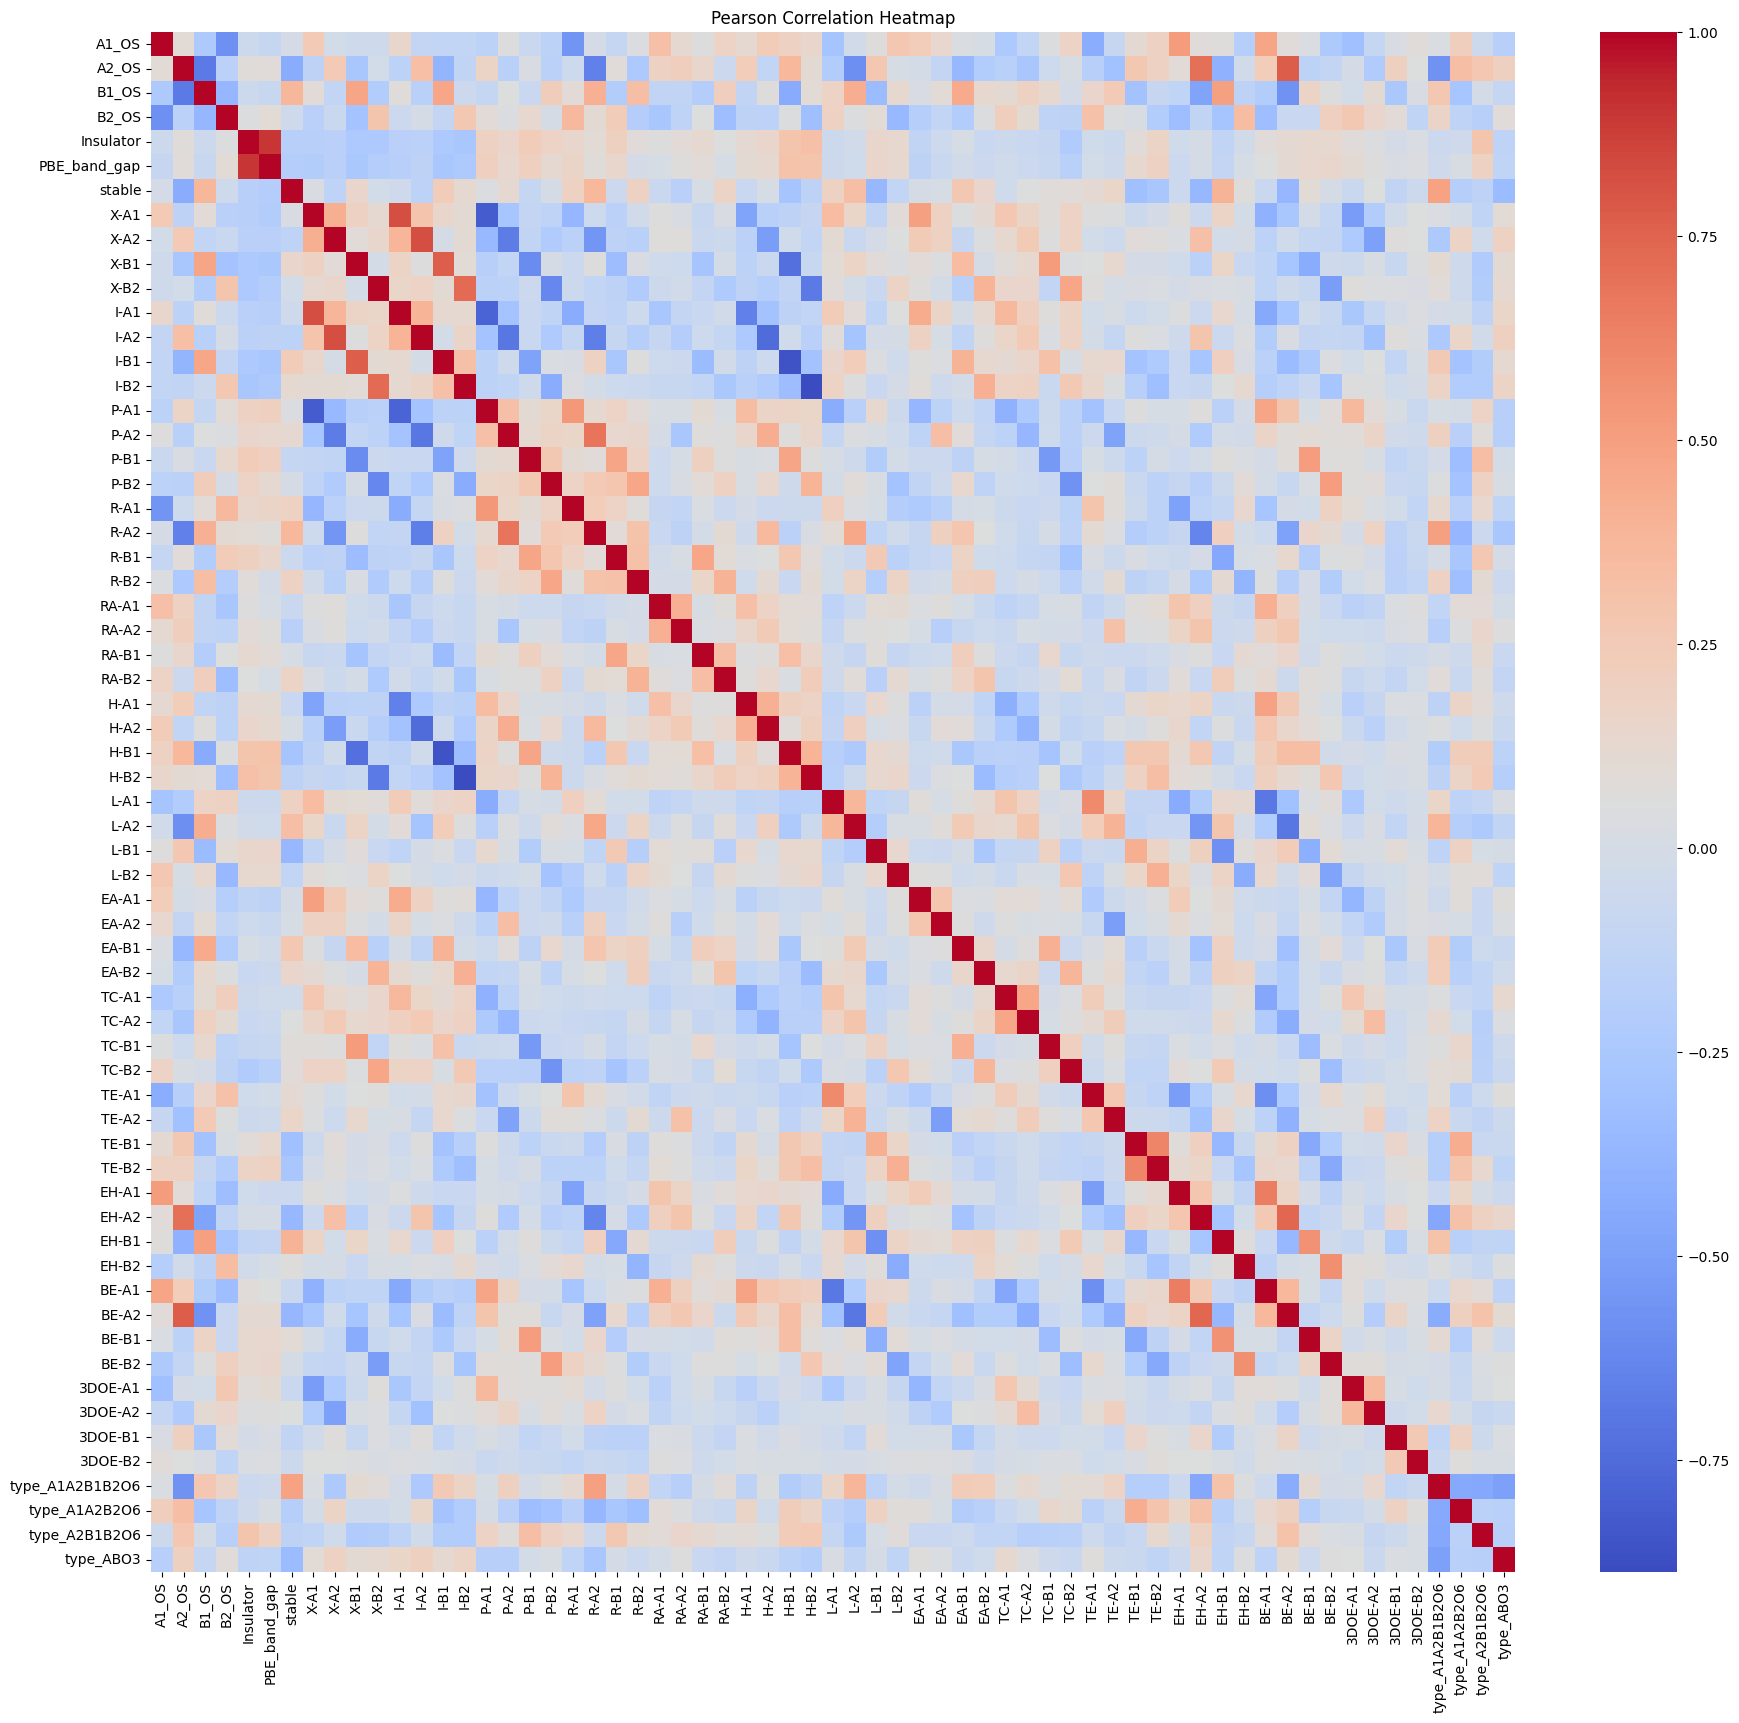

In [30]:
import seaborn as sns

# Calculate correlation matrices
pearson_corr_matrix = df.corr(method='pearson', numeric_only=True)

# Plot Pearson correlation heatmap
plt.figure(figsize=(22, 20))
sns.heatmap(pearson_corr_matrix, cmap='coolwarm', annot=False)
plt.title('Pearson Correlation Heatmap')
plt.show()

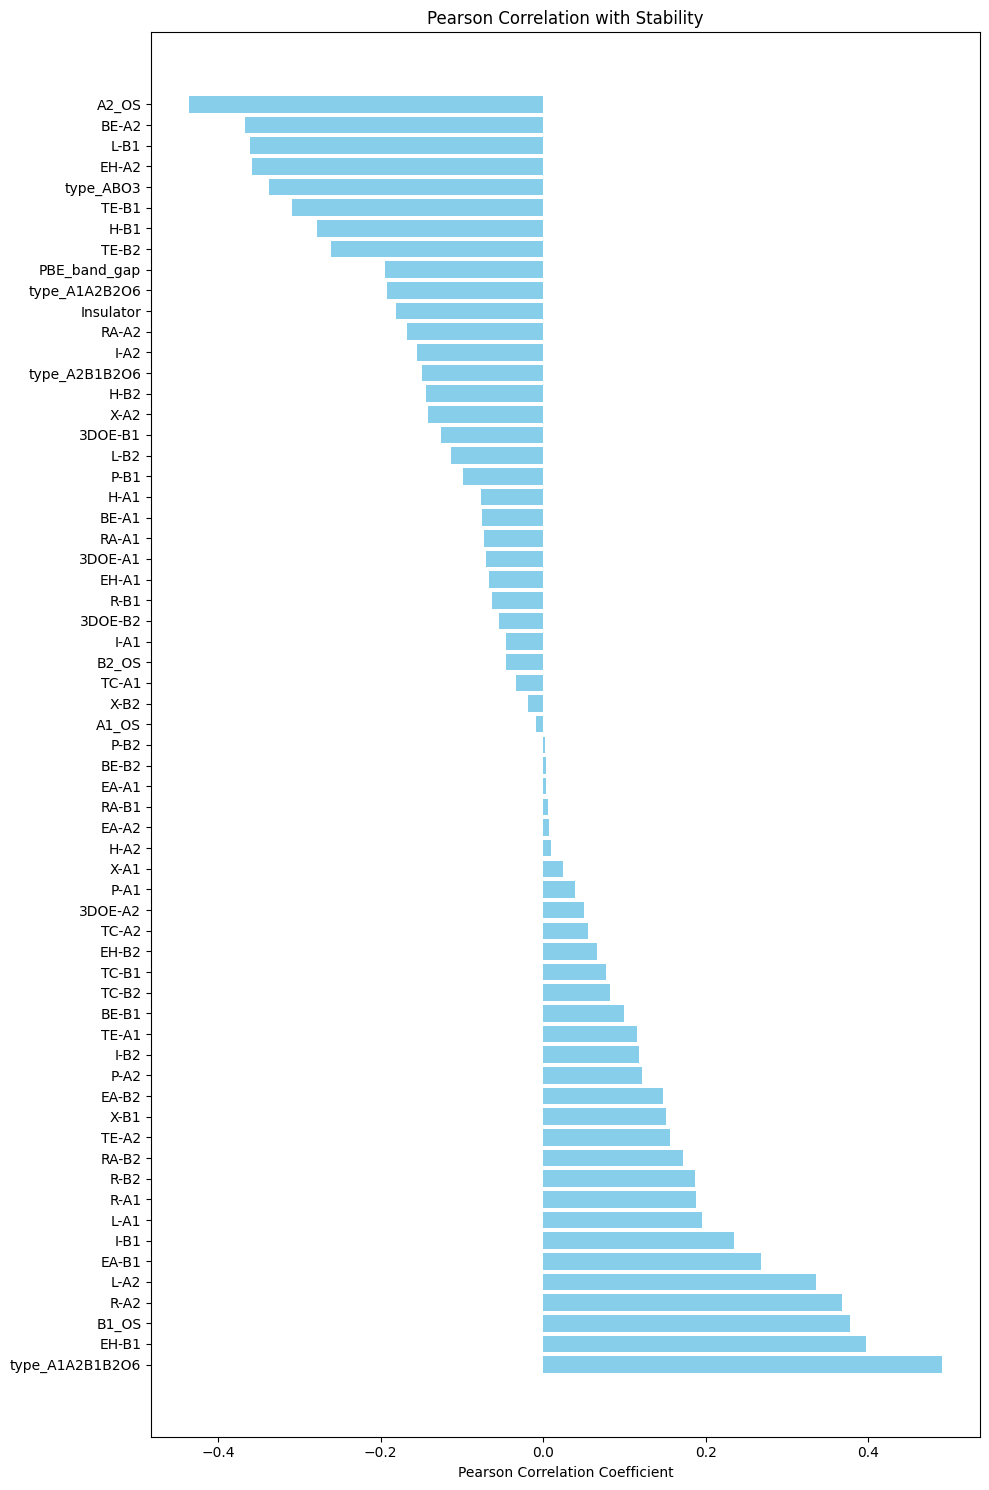

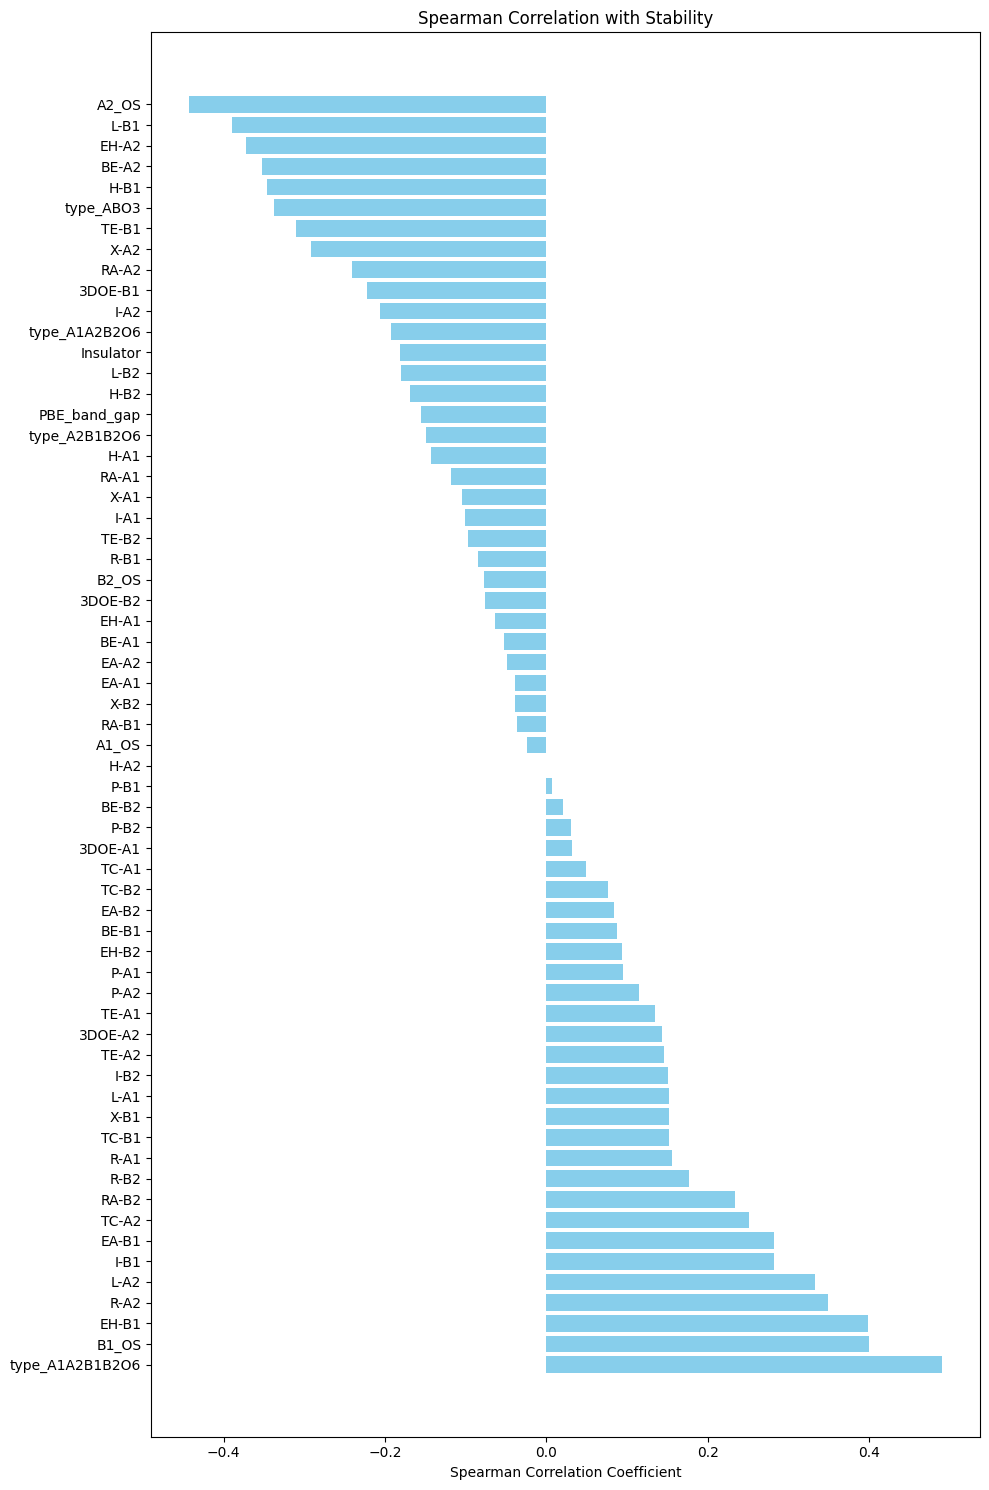

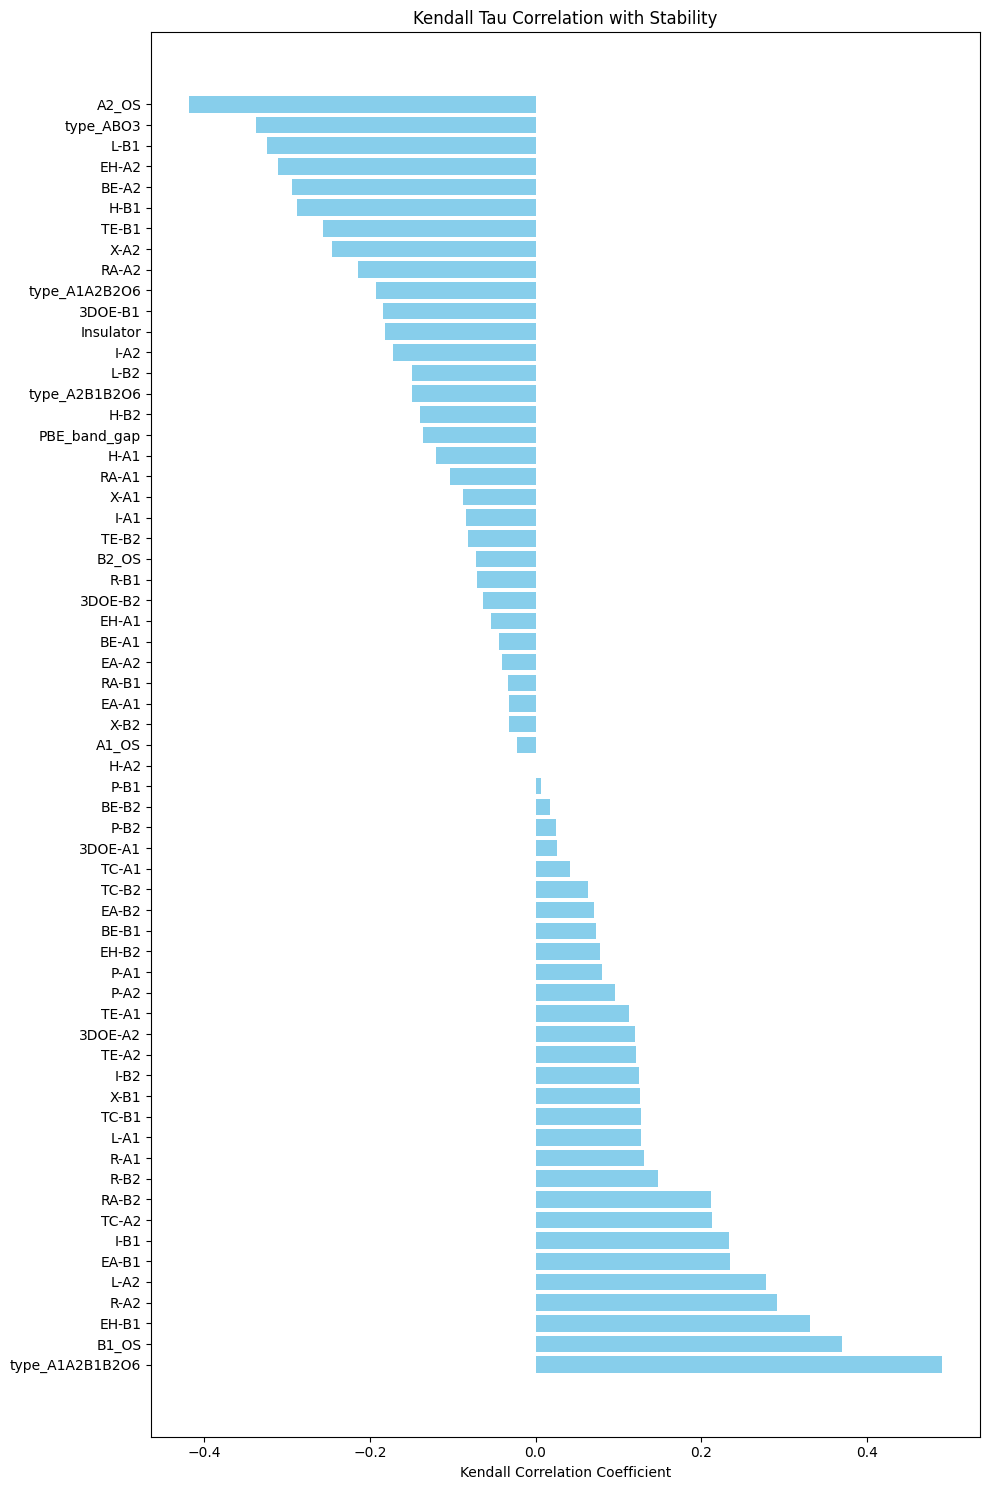

In [31]:
def plot_correlation_barplot(correlation_results, method, title):
    """Plots a horizontal barplot for correlation results."""
    correlations = {col: corrs[method] for col, corrs in correlation_results.items() if corrs[method] is not None}
    sorted_correlations = dict(sorted(correlations.items(), key=lambda item: item[1], reverse=True))

    plt.figure(figsize=(10, 15))
    plt.barh(list(sorted_correlations.keys()), list(sorted_correlations.values()), color='skyblue')
    plt.xlabel(f'{method} Correlation Coefficient')
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_correlation_barplot(correlation_results, 'Pearson', 'Pearson Correlation with Stability')
plot_correlation_barplot(correlation_results, 'Spearman', 'Spearman Correlation with Stability')
plot_correlation_barplot(correlation_results, 'Kendall', 'Kendall Tau Correlation with Stability')

In [32]:
df.drop(columns=['X-B2', 'A1_OS', 'P-B2', 'BE-B2','EA-A1','RA-B1', 'EA-A2','PBE_band_gap','Insulator'], inplace=True)

In [33]:
import random
import warnings
from sklearn.model_selection import train_test_split
from deap import base, creator, tools
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score


# Ignore potential warnings from XGBoost
warnings.filterwarnings('ignore')

# --- Configuration ---
# Order: learning_rate, max_depth, n_estimators, subsample, reg_lambda, reg_alpha, gamma, colsample_bylevel, colsample_bytree
HP_BOUNDS_LOW = [0.01, 3, 50, 0.5, 0, 0, 0, 0.5, 0.5]
HP_BOUNDS_HIGH = [0.3, 15, 500, 1.0, 10, 10, 5, 1.0, 1.0]
# 0: continuous, 1: discrete
HP_TYPES = [0, 1, 1, 0, 0, 0, 0, 0, 0]
NUM_HYPERPARAMETERS = len(HP_BOUNDS_LOW)

# Evolutionary Algorithm Parameters
POPULATION_SIZE = 50
NUM_GENERATIONS = 50
CXPB = 0.7  # Crossover probability
MUTPB = 0.3  # Mutation probability

# --- DEAP Setup ---
creator.create("FitnessMax", base.Fitness, weights=(1.0,))  # maximize accuracy
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()

# Attribute generator
def generate_hyperparameter(index):
    low = HP_BOUNDS_LOW[index]
    high = HP_BOUNDS_HIGH[index]
    if HP_TYPES[index] == 0:
        return random.uniform(low, high)
    else:
        return random.randint(low, high)

# Register attribute generators
for i in range(NUM_HYPERPARAMETERS):
    toolbox.register(f"attr_hp{i}", generate_hyperparameter, i)

# Structure initializer
toolbox.register("individual", tools.initCycle, creator.Individual,
                 tuple([toolbox.__getattribute__(f"attr_hp{i}") for i in range(NUM_HYPERPARAMETERS)]), n=1)

toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# --- Evaluation Function ---
def evalXGBC(individual, X_train, y_train, X_val, y_val):
    """Evaluate fitness by training XGBClassifier and returning accuracy."""
    hyperparameters = {
        'learning_rate': individual[0],
        'max_depth': int(individual[1]),
        'n_estimators': int(individual[2]),
        'subsample': individual[3],
        'reg_lambda': individual[4],
        'reg_alpha': individual[5],
        'gamma': individual[6],
        'colsample_bylevel': individual[7],
        'colsample_bytree': individual[8]
    }

    # Ensure valid values
    hyperparameters['max_depth'] = max(1, hyperparameters['max_depth'])
    hyperparameters['n_estimators'] = max(1, hyperparameters['n_estimators'])

    try:
        model = XGBClassifier(
            objective='binary:logistic',
            use_label_encoder=False,
            eval_metric='logloss',
            random_state=42,
            **hyperparameters
        )
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        acc = accuracy_score(y_val, preds)
        return (acc,)
    except Exception:
        return (0.0,)  # worst fitness if training fails

# Placeholder registration
toolbox.register("evaluate", evalXGBC, X_train=None, y_train=None, X_val=None, y_val=None)

# --- Genetic Operators ---
toolbox.register("mate", tools.cxTwoPoint)

def mutate_hyperparameters(individual, mu, sigma, indpb):
    for i, hp_type in enumerate(HP_TYPES):
        if random.random() < indpb:
            if hp_type == 0:
                individual[i] += random.gauss(mu, sigma[i])
                individual[i] = max(HP_BOUNDS_LOW[i], min(HP_BOUNDS_HIGH[i], individual[i]))
            else:
                individual[i] = random.randint(HP_BOUNDS_LOW[i], HP_BOUNDS_HIGH[i])
    return individual,

hp_ranges = [high - low for low, high in zip(HP_BOUNDS_LOW, HP_BOUNDS_HIGH)]
mutation_sigma = [r * 0.1 for r in hp_ranges]
toolbox.register("mutate", mutate_hyperparameters, mu=0, sigma=mutation_sigma, indpb=0.1)

toolbox.register("select", tools.selTournament, tournsize=3)

# --- Evolutionary Algorithm with Early Stopping ---
def eaSimpleWithEarlyStop(population, toolbox, cxpb, mutpb, ngen, stats=None,
                          halloffame=None, verbose=__debug__, patience=5):

    logbook = tools.Logbook()
    logbook.header = ['gen', 'nevals'] + (stats.fields if stats else [])

    # Evaluate the initial population
    fitnesses = list(map(toolbox.evaluate, population))
    for ind, fit in zip(population, fitnesses):
        ind.fitness.values = fit

    if halloffame is not None:
        halloffame.update(population)

    record = stats.compile(population) if stats else {}
    logbook.record(gen=0, nevals=len(population), **record)
    if verbose:
        print(logbook.stream)

    # --- Early stopping vars ---
    best_so_far = max(ind.fitness.values[0] for ind in population)
    no_improve_count = 0

    for gen in range(1, ngen + 1):
        offspring = toolbox.select(population, len(population))
        offspring = list(map(toolbox.clone, offspring))

        # Apply crossover and mutation
        for child1, child2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < cxpb:
                toolbox.mate(child1, child2)
                del child1.fitness.values
                del child2.fitness.values

        for mutant in offspring:
            if random.random() < mutpb:
                toolbox.mutate(mutant)
                del mutant.fitness.values

        # Evaluate invalid individuals
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = map(toolbox.evaluate, invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

        # Replace population
        population[:] = offspring

        if halloffame is not None:
            halloffame.update(population)

        record = stats.compile(population) if stats else {}
        logbook.record(gen=gen, nevals=len(invalid_ind), **record)
        if verbose:
            print(logbook.stream)

        # --- Early stopping check (maximize) ---
        current_best = max(ind.fitness.values[0] for ind in population)
        if current_best > best_so_far:
            best_so_far = current_best
            no_improve_count = 0
        else:
            no_improve_count += 1

        if no_improve_count >= patience:
            if verbose:
                print(f"\nEarly stopping triggered at generation {gen} "
                      f"(no improvement for {patience} generations).")
            break

    return population, logbook

# --- Main Loop ---
if __name__ == '__main__':


    y_total = df["stable"]
    X_total = df.drop(["stable"],axis=1)

    X_train, X_test, y_train, y_test = train_test_split(X_total,y_total,test_size=0.2,random_state=101)

   

    toolbox.unregister("evaluate")
    toolbox.register("evaluate", evalXGBC, X_train=X_train, y_train=y_train, X_val=X_test, y_val=y_test)

    print(f"Creating initial population of size {POPULATION_SIZE}...")
    population = toolbox.population(n=POPULATION_SIZE)

    hof = tools.HallOfFame(1)

    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("std", np.std)
    stats.register("min", np.min)
    stats.register("max", np.max)

    print(f"Starting evolutionary optimization for {NUM_GENERATIONS} generations...")
    population, logbook = eaSimpleWithEarlyStop(population, toolbox, cxpb=CXPB, mutpb=MUTPB,
                                                ngen=NUM_GENERATIONS, stats=stats,
                                                halloffame=hof, verbose=True, patience=5)

    print("\n--- Optimization Results ---")
    if hof:
        best_individual = hof[0]
        best_acc = best_individual.fitness.values[0]
        optimal_hyperparameters = {
            'learning_rate': best_individual[0],
            'max_depth': int(best_individual[1]),
            'n_estimators': int(best_individual[2]),
            'subsample': best_individual[3],
            'reg_lambda': best_individual[4],
            'reg_alpha': best_individual[5],
            'gamma': best_individual[6],
            'colsample_bylevel': best_individual[7],
            'colsample_bytree': best_individual[8]
        }

Creating initial population of size 50...
Starting evolutionary optimization for 50 generations...
gen	nevals	avg     	std       	min     	max     
0  	50    	0.942017	0.00972313	0.907856	0.968962
1  	40    	0.947507	0.00807701	0.931135	0.970902
2  	40    	0.953889	0.00829892	0.941804	0.970902
3  	42    	0.96033 	0.00754118	0.943744	0.971872
4  	35    	0.966421	0.00521924	0.951503	0.974782
5  	39    	0.969079	0.00253403	0.960233	0.974782
6  	45    	0.970029	0.00234595	0.963143	0.974782
7  	40    	0.970883	0.00284764	0.963143	0.974782
8  	40    	0.971891	0.0030394 	0.963143	0.974782
9  	41    	0.972435	0.00341598	0.957323	0.974782

Early stopping triggered at generation 9 (no improvement for 5 generations).

--- Optimization Results ---


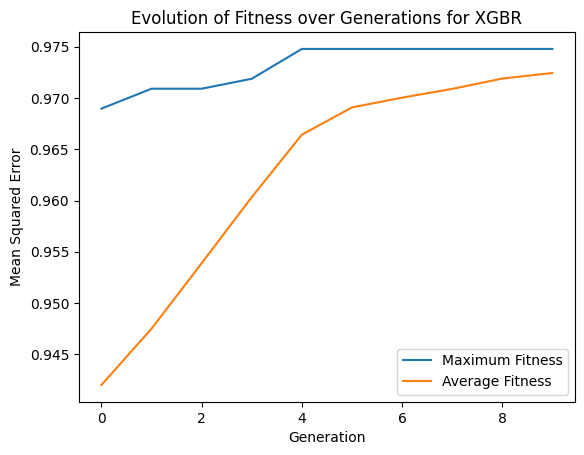

In [34]:
# Plot the statistics
import matplotlib.pyplot as plt
gen = logbook.select("gen")
max_fit = logbook.select("max")
avg_fit = logbook.select("avg")
plt.plot(gen, max_fit, label="Maximum Fitness")
plt.plot(gen, avg_fit, label="Average Fitness")
plt.xlabel("Generation")
plt.ylabel("Mean Squared Error")
plt.title("Evolution of Fitness over Generations for XGBR")
plt.legend()
plt.show()

In [35]:
XGBC_model = XGBClassifier(
            objective='binary:logistic',
            use_label_encoder=False,
            eval_metric='logloss',
            random_state=42,
            **optimal_hyperparameters
        )

XGBC_model.fit(X_train, y_train)
print("\nXGBR model trained with optimal hyperparameters.")
y_pred = XGBC_model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_acc:.4f}")


XGBR model trained with optimal hyperparameters.
Test Accuracy: 0.9748


In [36]:
import joblib
import os

model_dir = "../model/stable"
os.makedirs(model_dir, exist_ok=True)

joblib.dump(XGBC_model, os.path.join(model_dir, "XGBC_model.joblib"))

['../model/stable/XGBC_model.joblib']

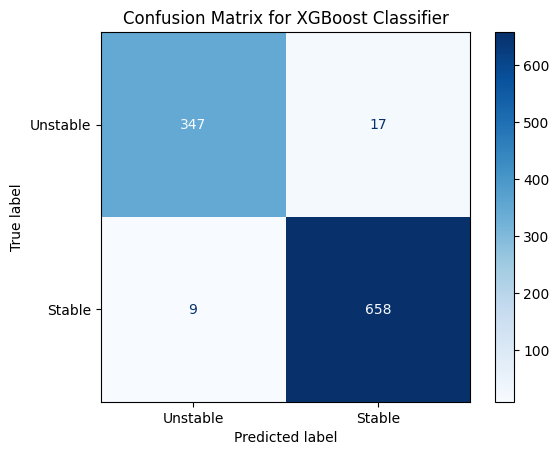

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Unstable", "Stable"], cmap="Blues")
plt.title("Confusion Matrix for XGBoost Classifier")
plt.show()

In [38]:
from sklearn.tree import DecisionTreeClassifier


# Ignore potential warnings
warnings.filterwarnings('ignore')

# --- Configuration for Decision Tree ---
# Order: max_depth, min_samples_split, min_samples_leaf, max_features, criterion, splitter
# For categorical params:
# - max_features options index: [0=None, 1='sqrt', 2='log2']
# - criterion options index: [0='gini', 1='entropy']  # keep to widely compatible options
# - splitter options index: [0='best', 1='random']

HP_BOUNDS_LOW  = [1, 2, 1, 0, 0, 0]
HP_BOUNDS_HIGH = [40, 50, 20, 2, 1, 1]
# 0: continuous, 1: integer, 2: categorical-index (integer but mapped to strings)
HP_TYPES = [1, 1, 1, 2, 2, 2]
NUM_HYPERPARAMETERS = len(HP_BOUNDS_LOW)

MAX_FEATURES_OPTS = [None, 'sqrt', 'log2']
CRITERION_OPTS    = ['gini', 'entropy']
SPLITTER_OPTS     = ['best', 'random']

# --- DEAP Setup ---
creator.create("FitnessMax", base.Fitness, weights=(1.0,))  # maximize accuracy
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()

# Attribute generator
def generate_hyperparameter(index):
    low = HP_BOUNDS_LOW[index]
    high = HP_BOUNDS_HIGH[index]
    hp_type = HP_TYPES[index]
    if hp_type == 0:
        return random.uniform(low, high)
    else:
        # both integer and categorical indices use randint for generation
        return random.randint(low, high)

# Register attribute generators
for i in range(NUM_HYPERPARAMETERS):
    toolbox.register(f"attr_hp{i}", generate_hyperparameter, i)

# Structure initializer
toolbox.register(
    "individual",
    tools.initCycle,
    creator.Individual,
    tuple([toolbox.__getattribute__(f"attr_hp{i}") for i in range(NUM_HYPERPARAMETERS)]),
    n=1
)

toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# --- Mapping helper for categorical indices ---
def map_dt_hyperparameters(individual):
    return {
        'max_depth': int(individual[0]),
        'min_samples_split': int(individual[1]),
        'min_samples_leaf': int(individual[2]),
        'max_features': MAX_FEATURES_OPTS[int(individual[3])],
        'criterion': CRITERION_OPTS[int(individual[4])],
        'splitter': SPLITTER_OPTS[int(individual[5])]
    }

# --- Evaluation Function ---
def evalDTC(individual, X_train, y_train, X_val, y_val):
    """Evaluate fitness by training DecisionTreeClassifier and returning accuracy."""
    hp = map_dt_hyperparameters(individual)

    # Ensure valid values
    hp['max_depth'] = max(1, hp['max_depth'])
    hp['min_samples_split'] = max(2, hp['min_samples_split'])
    hp['min_samples_leaf'] = max(1, hp['min_samples_leaf'])

    try:
        model = DecisionTreeClassifier(
            random_state=42,
            **hp
        )
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        acc = accuracy_score(y_val, preds)
        return (acc,)
    except Exception:
        return (0.0,)  # worst fitness if training fails

# Placeholder registration
toolbox.register("evaluate", evalDTC, X_train=None, y_train=None, X_val=None, y_val=None)

# --- Genetic Operators ---
toolbox.register("mate", tools.cxTwoPoint)

def mutate_hyperparameters(individual, mu, sigma, indpb):
    for i, hp_type in enumerate(HP_TYPES):
        if random.random() < indpb:
            if hp_type == 0:
                # continuous (not used here, but kept for pattern consistency)
                individual[i] += random.gauss(mu, sigma[i])
                individual[i] = max(HP_BOUNDS_LOW[i], min(HP_BOUNDS_HIGH[i], individual[i]))
            elif hp_type == 1:
                # integer
                individual[i] = random.randint(HP_BOUNDS_LOW[i], HP_BOUNDS_HIGH[i])
            else:
                # categorical index: resample a valid index
                individual[i] = random.randint(HP_BOUNDS_LOW[i], HP_BOUNDS_HIGH[i])
    return individual,

hp_ranges = [high - low for low, high in zip(HP_BOUNDS_LOW, HP_BOUNDS_HIGH)]
mutation_sigma = [max(1.0, r * 0.1) for r in hp_ranges]  # ensure sigma >= 1 for integer steps
toolbox.register("mutate", mutate_hyperparameters, mu=0, sigma=mutation_sigma, indpb=0.1)

toolbox.register("select", tools.selTournament, tournsize=3)

# --- Evolutionary Algorithm with Early Stopping ---
def eaSimpleWithEarlyStop(population, toolbox, cxpb, mutpb, ngen, stats=None,
                          halloffame=None, verbose=__debug__, patience=5):

    logbook = tools.Logbook()
    logbook.header = ['gen', 'nevals'] + (stats.fields if stats else [])

    # Evaluate the initial population
    fitnesses = list(map(toolbox.evaluate, population))
    for ind, fit in zip(population, fitnesses):
        ind.fitness.values = fit

    if halloffame is not None:
        halloffame.update(population)

    record = stats.compile(population) if stats else {}
    logbook.record(gen=0, nevals=len(population), **record)
    if verbose:
        print(logbook.stream)

    # --- Early stopping vars ---
    best_so_far = max(ind.fitness.values[0] for ind in population)
    no_improve_count = 0

    for gen in range(1, ngen + 1):
        offspring = toolbox.select(population, len(population))
        offspring = list(map(toolbox.clone, offspring))

        # Apply crossover and mutation
        for child1, child2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < cxpb:
                toolbox.mate(child1, child2)
                del child1.fitness.values
                del child2.fitness.values

        for mutant in offspring:
            if random.random() < mutpb:
                toolbox.mutate(mutant)
                del mutant.fitness.values

        # Evaluate invalid individuals
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = map(toolbox.evaluate, invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

        # Replace population
        population[:] = offspring

        if halloffame is not None:
            halloffame.update(population)

        record = stats.compile(population) if stats else {}
        logbook.record(gen=gen, nevals=len(invalid_ind), **record)
        if verbose:
            print(logbook.stream)

        # --- Early stopping check (maximize) ---
        current_best = max(ind.fitness.values[0] for ind in population)
        if current_best > best_so_far:
            best_so_far = current_best
            no_improve_count = 0
        else:
            no_improve_count += 1

        if no_improve_count >= patience:
            if verbose:
                print(f"\nEarly stopping triggered at generation {gen} "
                      f"(no improvement for {patience} generations).")
            break

    return population, logbook

# --- Main Loop ---
if __name__ == '__main__':
    # Expect df with target column "stable"
    y_total = df["stable"]
    X_total = df.drop(["stable"], axis=1)

    X_train, X_test, y_train, y_test = train_test_split(
        X_total, y_total, test_size=0.2, random_state=101, stratify=y_total
    )

    toolbox.unregister("evaluate")
    toolbox.register("evaluate", evalDTC, X_train=X_train, y_train=y_train, X_val=X_test, y_val=y_test)

    POPULATION_SIZE = 50
    NUM_GENERATIONS = 50
    CXPB = 0.7
    MUTPB = 0.3

    print(f"Creating initial population of size {POPULATION_SIZE}...")
    population = toolbox.population(n=POPULATION_SIZE)

    hof = tools.HallOfFame(1)

    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("std", np.std)
    stats.register("min", np.min)
    stats.register("max", np.max)

    print(f"Starting evolutionary optimization for {NUM_GENERATIONS} generations...")
    population, logbook = eaSimpleWithEarlyStop(
        population, toolbox, cxpb=CXPB, mutpb=MUTPB,
        ngen=NUM_GENERATIONS, stats=stats,
        halloffame=hof, verbose=True, patience=5
    )

    print("\n--- Optimization Results (Decision Tree) ---")
    if hof:
        best_individual = hof[0]
        best_acc = best_individual.fitness.values[0]
        optimal_hyperparameters = map_dt_hyperparameters(best_individual)

        print(f"Best validation accuracy: {best_acc:.4f}")
        print("Best hyperparameters:")
        for k, v in optimal_hyperparameters.items():
            print(f"  {k}: {v}")

        # Train final model on full training data with best params
        final_model = DecisionTreeClassifier(random_state=42, **optimal_hyperparameters)
        final_model.fit(X_train, y_train)
        test_acc = accuracy_score(y_test, final_model.predict(X_test))
        print(f"Final test accuracy: {test_acc:.4f}")

Creating initial population of size 50...
Starting evolutionary optimization for 50 generations...
gen	nevals	avg     	std      	min     	max     
0  	50    	0.884733	0.0641202	0.635306	0.955383
1  	41    	0.917013	0.028735 	0.790495	0.955383
2  	45    	0.930223	0.0248715	0.790495	0.957323
3  	43    	0.93934 	0.0161093	0.886518	0.957323
4  	44    	0.944772	0.0133109	0.903007	0.958293
5  	36    	0.95259 	0.00926402	0.902037	0.958293
6  	39    	0.953249	0.0109116 	0.901067	0.958293
7  	37    	0.956275	0.004755  	0.929195	0.958293
8  	40    	0.954821	0.0124576 	0.874879	0.958293
9  	41    	0.956819	0.00624154	0.915616	0.958293

Early stopping triggered at generation 9 (no improvement for 5 generations).

--- Optimization Results (Decision Tree) ---
Best validation accuracy: 0.9583
Best hyperparameters:
  max_depth: 12
  min_samples_split: 2
  min_samples_leaf: 10
  max_features: None
  criterion: gini
  splitter: best
Final test accuracy: 0.9583


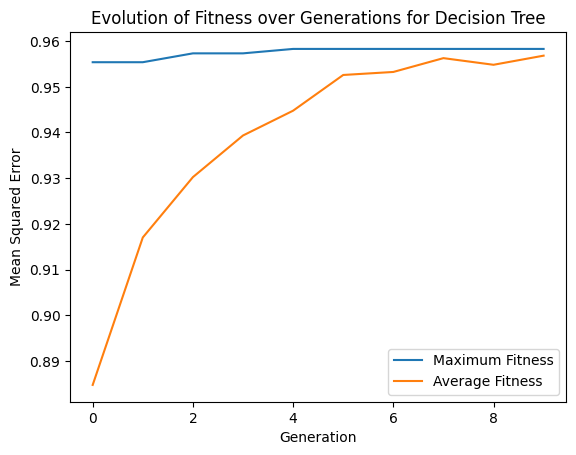

In [39]:
# Plot the statistics
import matplotlib.pyplot as plt
gen = logbook.select("gen")
max_fit = logbook.select("max")
avg_fit = logbook.select("avg")
plt.plot(gen, max_fit, label="Maximum Fitness")
plt.plot(gen, avg_fit, label="Average Fitness")
plt.xlabel("Generation")
plt.ylabel("Mean Squared Error")
plt.title("Evolution of Fitness over Generations for Decision Tree")
plt.legend()
plt.show()

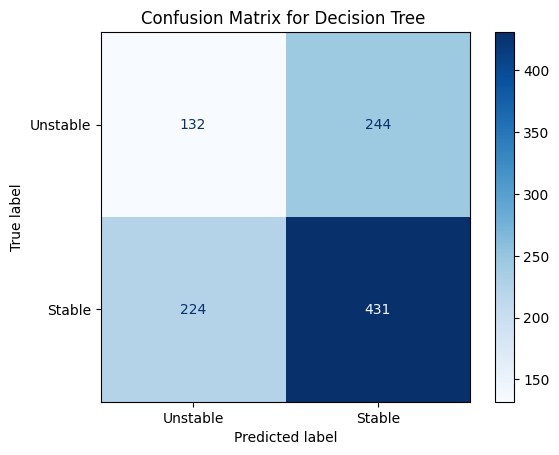

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Unstable", "Stable"], cmap="Blues")
plt.title("Confusion Matrix for Decision Tree ")
plt.show()

In [41]:
joblib.dump(final_model, os.path.join(model_dir, "DT_model.joblib"))

['../model/stable/DT_model.joblib']